<a href="https://www.kaggle.com/code/sonawanelalitsunil/anemia-detection-ml-100?scriptVersionId=236297281" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/anemia-detection-dataset/anemia_dataset.csv


## Title : Anemia Detection Dataset

#### Description:
Clinical and demographic data for identifying and analyzing anemia in patients, supporting diagnostic and research efforts.



## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/anemia-detection-dataset/anemia_dataset.csv')

In [3]:
df.head()

,Number,Name,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,1,Jafor Alam,43.2555,30.8421,25.9025,6.3,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,khadiza,45.6033,28.1900,26.2067,13.5,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Lalu,45.0107,28.9677,26.0215,11.7,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Mira nath,44.5398,28.9899,26.4703,13.5,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,monoara,43.2870,30.6972,26.0158,12.4,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,Number,Name,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
99,100,Anik,49.9999,29.2860,20.7141,14.5,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,101,Haradhan,42.2324,30.6757,27.0919,6.3,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN
101,102,arefa,45.6064,31.9084,22.4852,12.7,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
102,103,diluara,45.2095,29.2769,25.5136,13.4,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN
103,104,Hasina,43.5706,29.8094,26.6199,12.2,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        104 non-null    int64  
 1   Name          104 non-null    object 
 2   %Red Pixel    104 non-null    float64
 3   %Green pixel  104 non-null    float64
 4   %Blue pixel   104 non-null    float64
 5   Hb            104 non-null    float64
 6   Anaemic       104 non-null    object 
 7   Unnamed: 7    0 non-null      float64
 8   Unnamed: 8    0 non-null      float64
 9   Unnamed: 9    0 non-null      float64
 10  Unnamed: 10   0 non-null      float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   0 non-null      float64
 13  Unnamed: 13   1 non-null      object 
dtypes: float64(10), int64(1), object(3)
memory usage: 11.5+ KB


In [6]:
df.describe()

,Number,%Red Pixel,%Green pixel,%Blue pixel,Hb,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
count,104.000000,104.000000,104.000000,104.000000,104.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,52.500000,45.654175,28.875507,25.470325,12.150962,NaN,NaN,NaN,NaN,NaN,NaN
std,30.166206,2.816294,1.554275,1.984671,2.512957,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,38.796800,25.140300,19.541300,2.800000,NaN,NaN,NaN,NaN,NaN,NaN
25%,26.750000,43.911375,27.871300,24.896425,10.650000,NaN,NaN,NaN,NaN,NaN,NaN
50%,52.500000,45.385350,28.948750,25.953200,12.600000,NaN,NaN,NaN,NaN,NaN,NaN
75%,78.250000,46.968325,29.887275,26.721600,14.000000,NaN,NaN,NaN,NaN,NaN,NaN
max,104.000000,54.647800,32.368100,29.841400,16.300000,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.isnull().sum()

Number            0
Name              0
%Red Pixel        0
%Green pixel      0
%Blue pixel       0
Hb                0
Anaemic           0
Unnamed: 7      104
Unnamed: 8      104
Unnamed: 9      104
Unnamed: 10     104
Unnamed: 11     104
Unnamed: 12     104
Unnamed: 13     103
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Number            int64
Name             object
%Red Pixel      float64
%Green pixel    float64
%Blue pixel     float64
Hb              float64
Anaemic          object
Unnamed: 7      float64
Unnamed: 8      float64
Unnamed: 9      float64
Unnamed: 10     float64
Unnamed: 11     float64
Unnamed: 12     float64
Unnamed: 13      object
dtype: object

In [10]:
df.shape

(104, 14)

In [11]:
df.columns

Index(['Number', 'Name', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb',
       'Anaemic', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

## Data visualizations

In [12]:
# Drop unnamed garbage columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

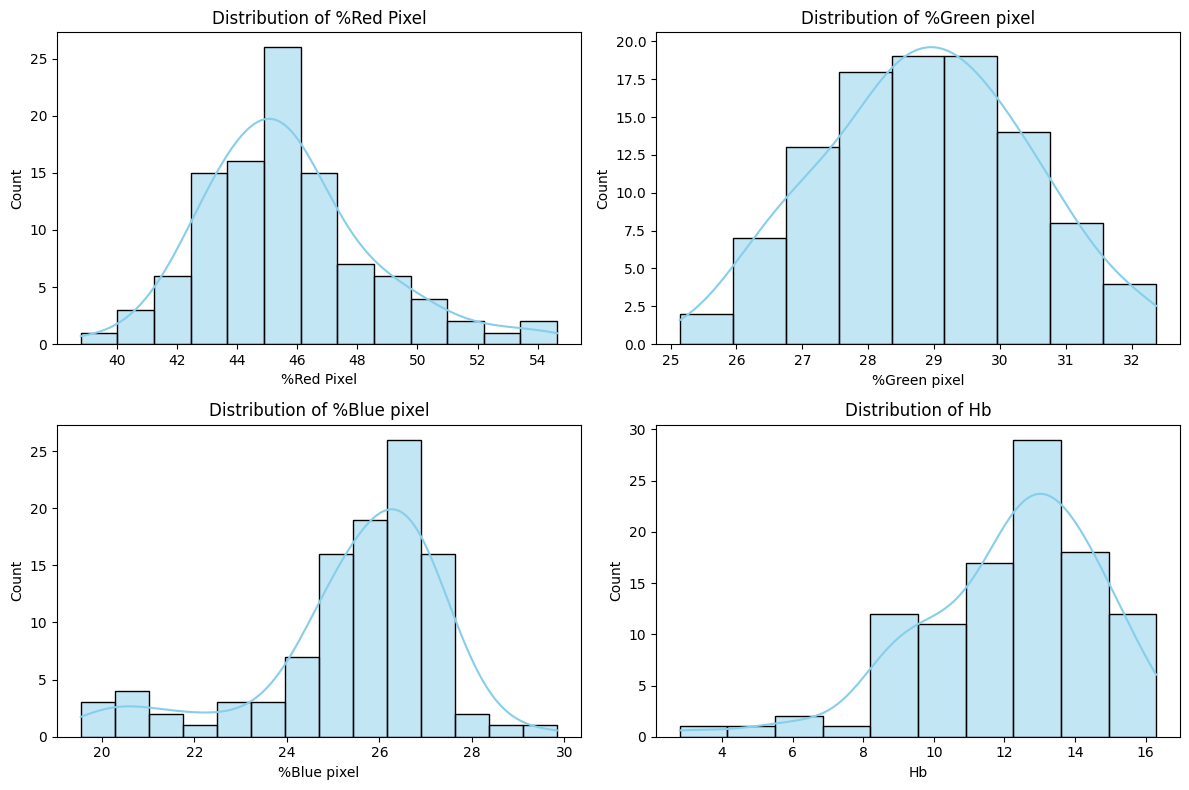

In [13]:
# 1. Distribution Histograms
features = ['%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb']

plt.figure(figsize=(12, 8))
for idx, feature in enumerate(features, 1):
    plt.subplot(2, 2, idx)
    sns.histplot(df[feature], kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()


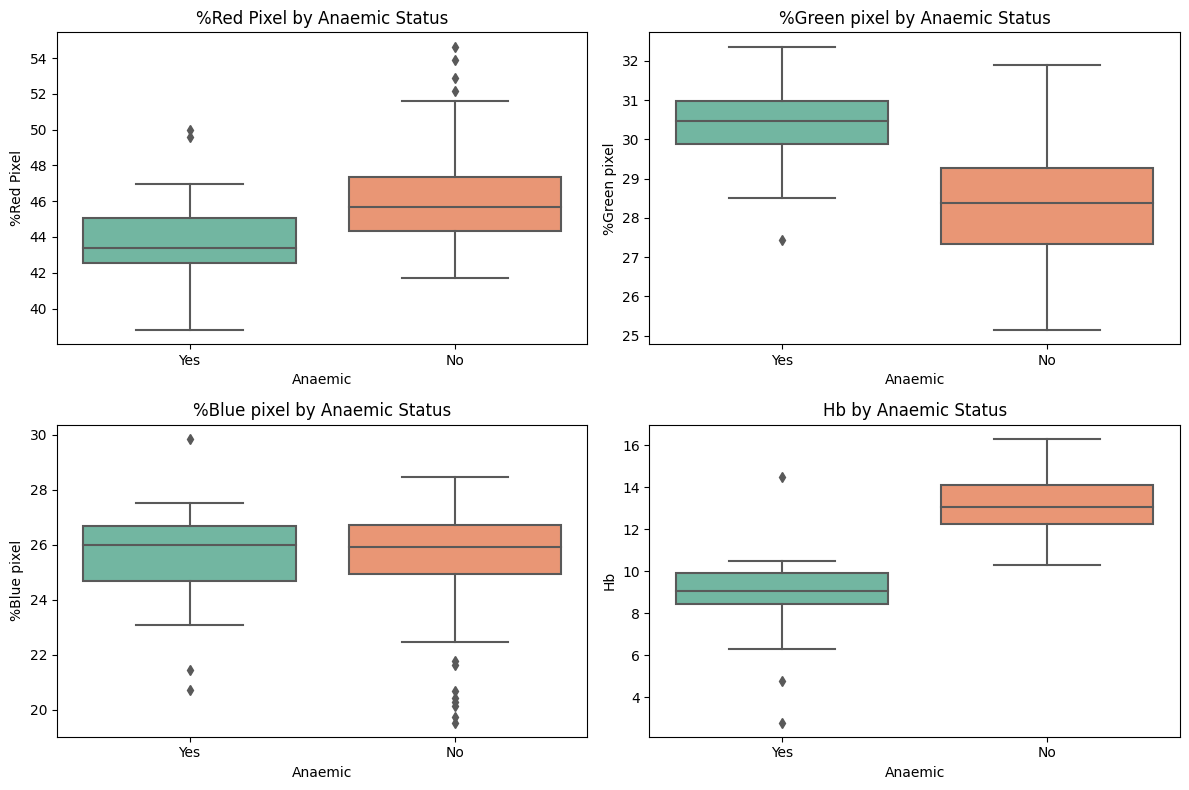

In [14]:
# 2. Boxplots grouped by Anaemic
plt.figure(figsize=(12, 8))
for idx, feature in enumerate(features, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(x='Anaemic', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Anaemic Status')
plt.tight_layout()
plt.show()

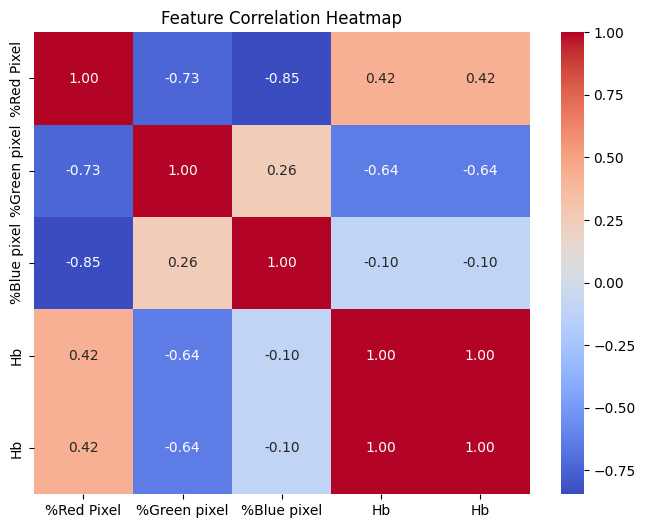

In [15]:
# 3. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[features + ['Hb']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()


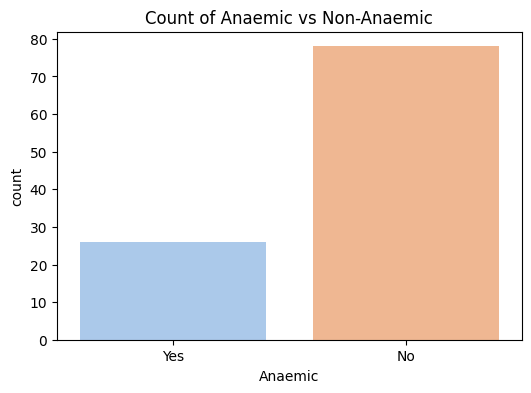

In [16]:
# 4. Countplot of Anaemic
plt.figure(figsize=(6, 4))
sns.countplot(x='Anaemic', data=df, palette='pastel')
plt.title('Count of Anaemic vs Non-Anaemic')
plt.show()

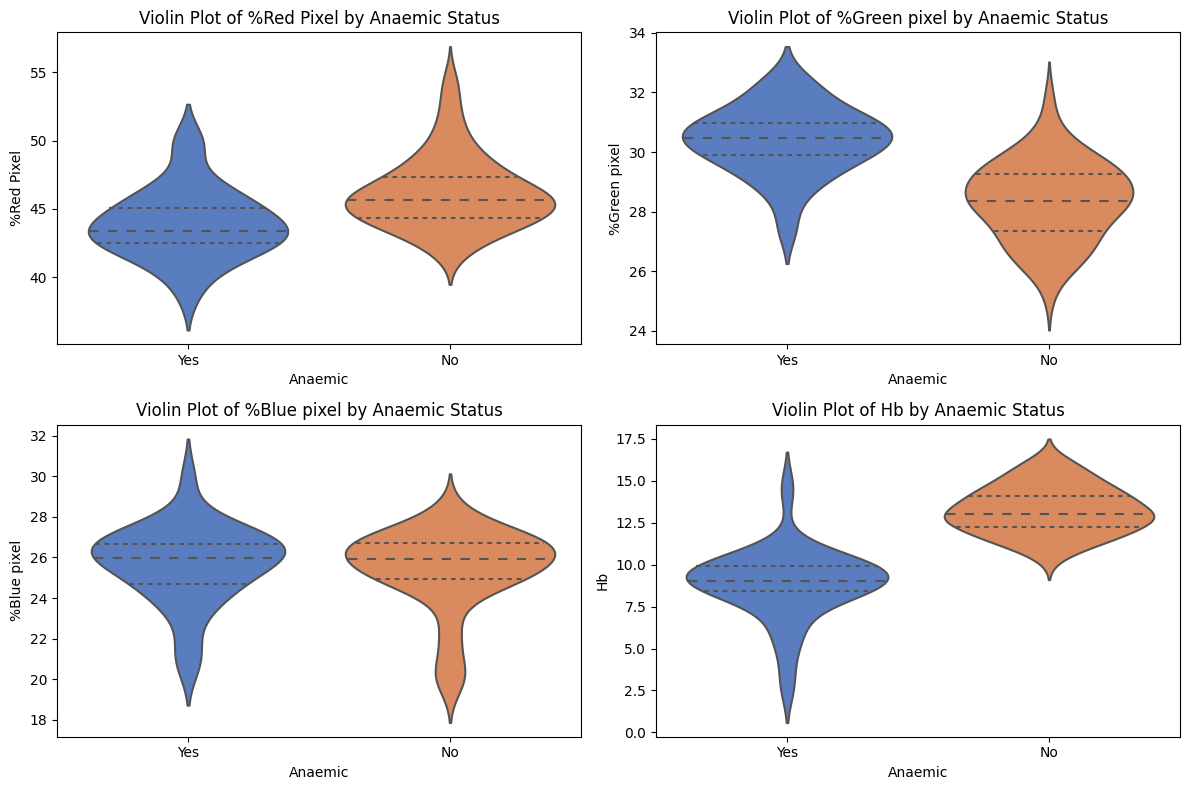

In [17]:
# 6. Violin Plots (distribution + density in one)
plt.figure(figsize=(12, 8))
for idx, feature in enumerate(features, 1):
    plt.subplot(2, 2, idx)
    sns.violinplot(x='Anaemic', y=feature, data=df, palette='muted', inner='quartile')
    plt.title(f'Violin Plot of {feature} by Anaemic Status')
plt.tight_layout()
plt.show()

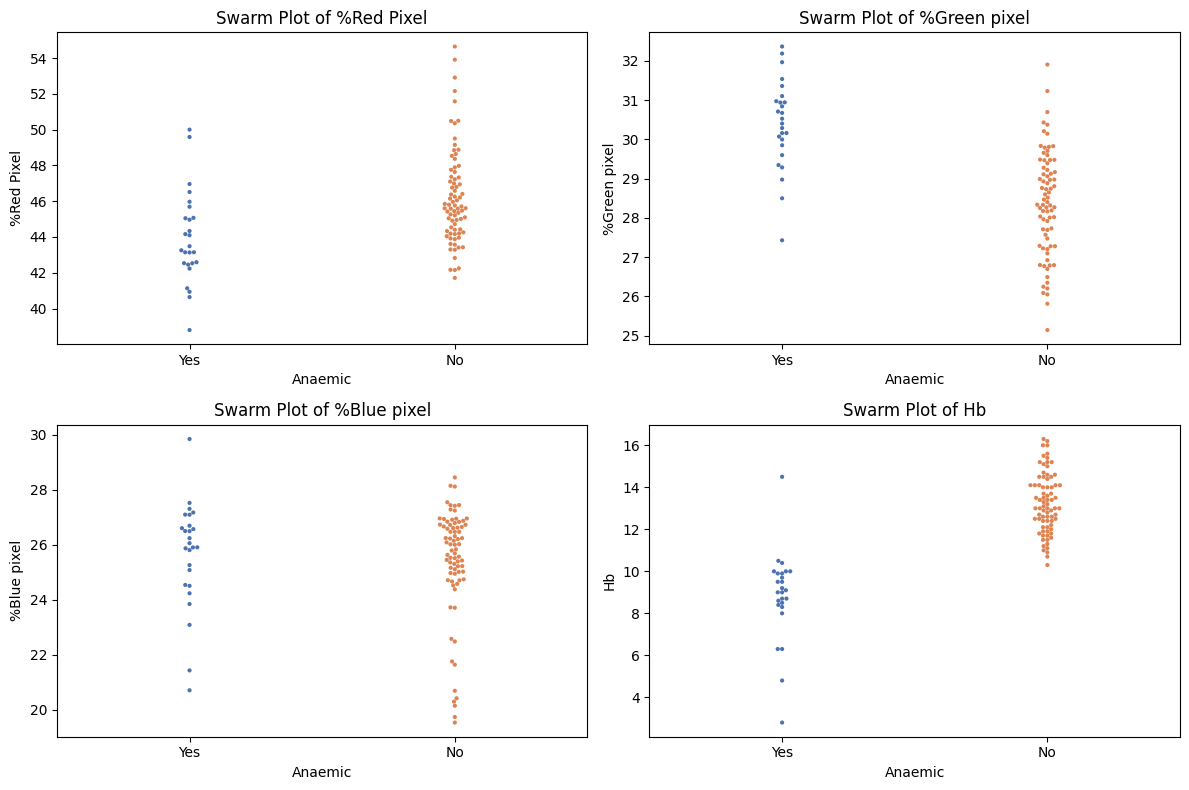

In [18]:
# 7. Swarmplots (individual data points)
plt.figure(figsize=(12, 8))
for idx, feature in enumerate(features, 1):
    plt.subplot(2, 2, idx)
    sns.swarmplot(x='Anaemic', y=feature, data=df, palette='deep', size=3)
    plt.title(f'Swarm Plot of {feature}')
plt.tight_layout()
plt.show()

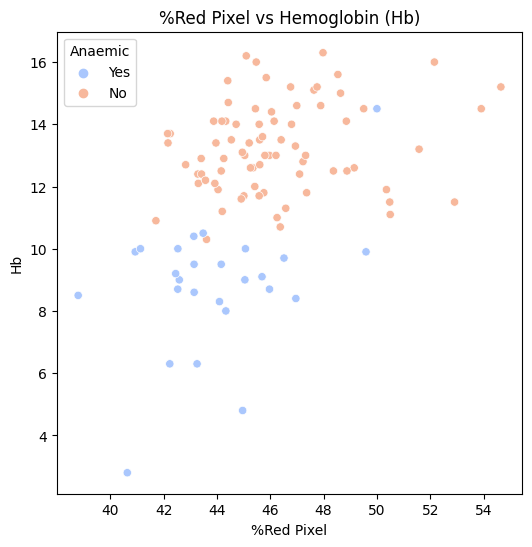

In [19]:
# 8. Scatter Plot: %Red Pixel vs Hb
plt.figure(figsize=(6, 6))
sns.scatterplot(x='%Red Pixel', y='Hb', hue='Anaemic', data=df, palette='coolwarm')
plt.title('%Red Pixel vs Hemoglobin (Hb)')
plt.show()

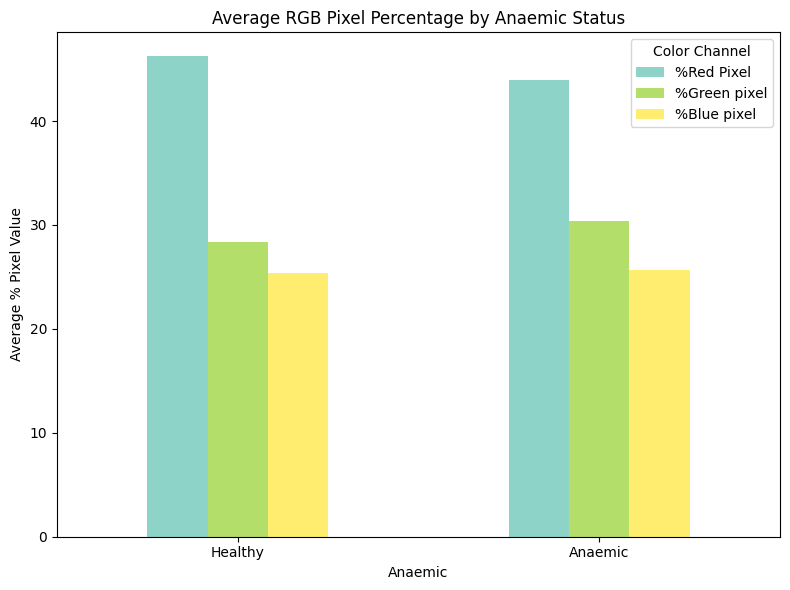

In [20]:
# 9. Bar plot of Average RGB values by Anaemic
avg_rgb = df.groupby('Anaemic')[['%Red Pixel', '%Green pixel', '%Blue pixel']].mean().reset_index()

avg_rgb.plot(x='Anaemic', kind='bar', figsize=(8, 6), colormap='Set3')
plt.title('Average RGB Pixel Percentage by Anaemic Status')
plt.ylabel('Average % Pixel Value')
plt.xticks([0, 1], ['Healthy', 'Anaemic'], rotation=0)
plt.legend(title='Color Channel')
plt.tight_layout()
plt.show()

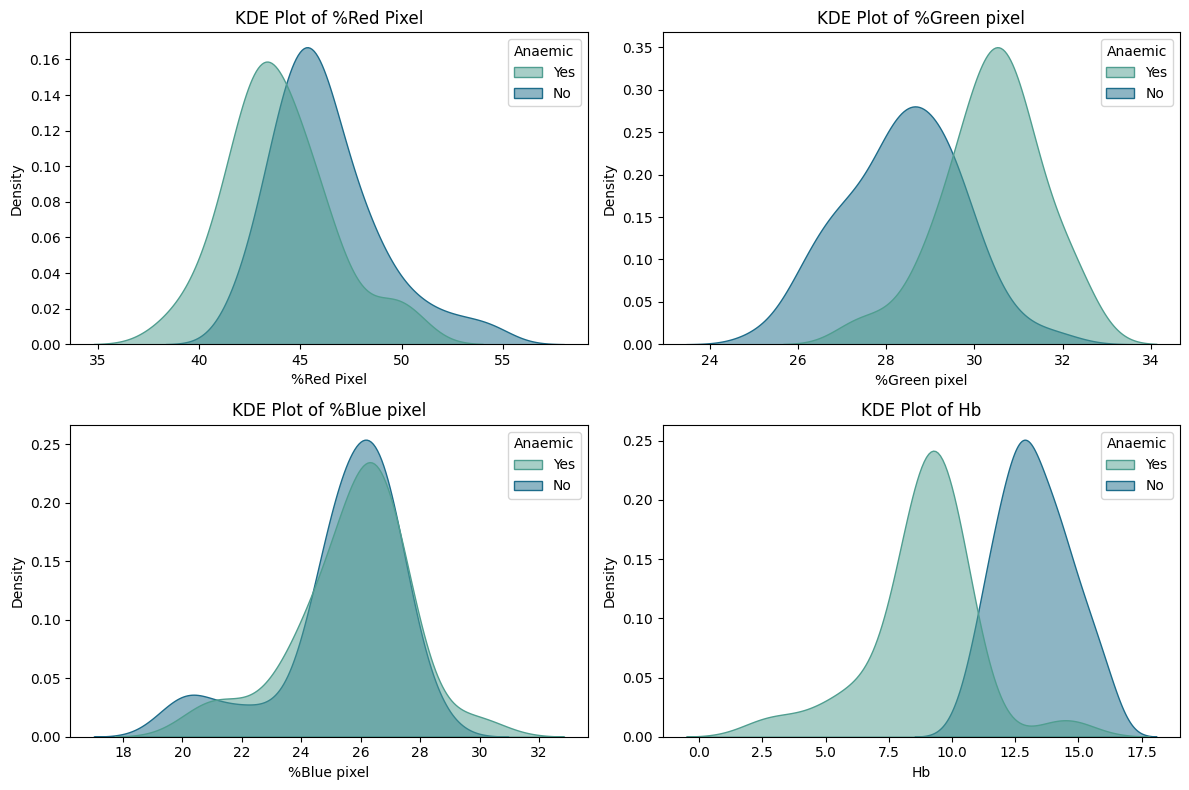

In [21]:
# 10. KDE plots (smooth distribution curves)
plt.figure(figsize=(12, 8))
for idx, feature in enumerate(features, 1):
    plt.subplot(2, 2, idx)
    sns.kdeplot(data=df, x=feature, hue='Anaemic', fill=True, common_norm=False, palette='crest', alpha=0.5)
    plt.title(f'KDE Plot of {feature}')
plt.tight_layout()
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [23]:
# 2. Drop Unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# 3. Check data
print(df.info())
print(df.head())

# 4. Encode 'Name' if needed
if df['Name'].dtype == 'object':
    le = LabelEncoder()
    df['Name'] = le.fit_transform(df['Name'])

# 5. Define Features (X) and Target (y)
features = ['%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb']
X = df[features]
y = df['Anaemic']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Number        104 non-null    int64  
 1   Name          104 non-null    object 
 2   %Red Pixel    104 non-null    float64
 3   %Green pixel  104 non-null    float64
 4   %Blue pixel   104 non-null    float64
 5   Hb            104 non-null    float64
 6   Anaemic       104 non-null    object 
dtypes: float64(4), int64(1), object(2)
memory usage: 5.8+ KB
None
   Number        Name  %Red Pixel  %Green pixel  %Blue pixel    Hb Anaemic
0       1  Jafor Alam     43.2555       30.8421      25.9025   6.3     Yes
1       2     khadiza     45.6033       28.1900      26.2067  13.5      No
2       3        Lalu     45.0107       28.9677      26.0215  11.7      No
3       4   Mira nath     44.5398       28.9899      26.4703  13.5      No
4       5     monoara     43.2870       30.6972      26.0158  12.4 

In [24]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 7. Models to try
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}


Train shape: (83, 4)
Test shape: (21, 4)



Training Logistic Regression...
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        16
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



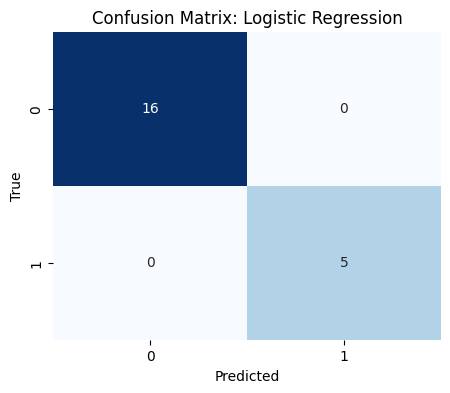


Training Decision Tree...
Accuracy: 0.9524
Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.94      0.97        16
         Yes       0.83      1.00      0.91         5

    accuracy                           0.95        21
   macro avg       0.92      0.97      0.94        21
weighted avg       0.96      0.95      0.95        21



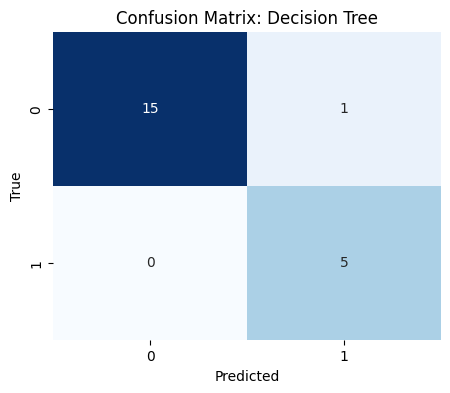


Training Random Forest...
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        16
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



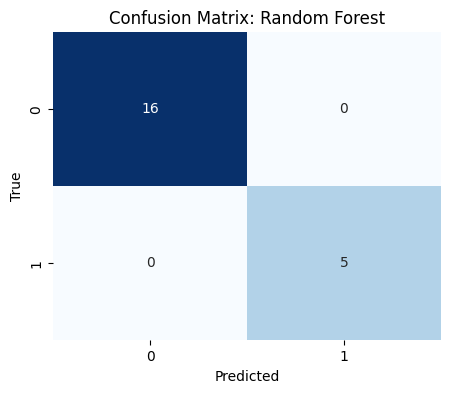


Training Support Vector Machine...
Accuracy: 0.9048
Classification Report:
              precision    recall  f1-score   support

          No       0.89      1.00      0.94        16
         Yes       1.00      0.60      0.75         5

    accuracy                           0.90        21
   macro avg       0.94      0.80      0.85        21
weighted avg       0.92      0.90      0.90        21



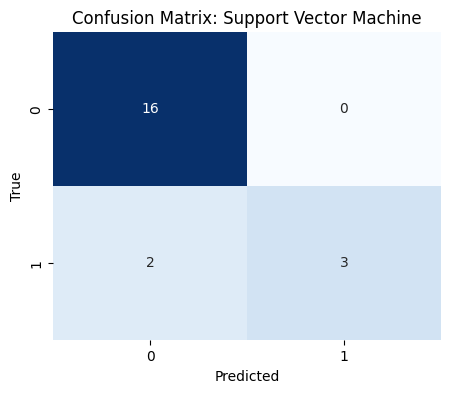


Training K-Nearest Neighbors...
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        16
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



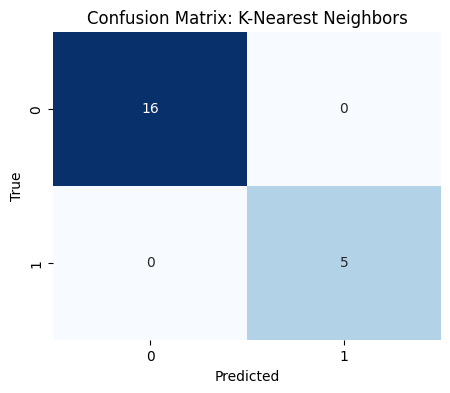


Training Naive Bayes...
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        16
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



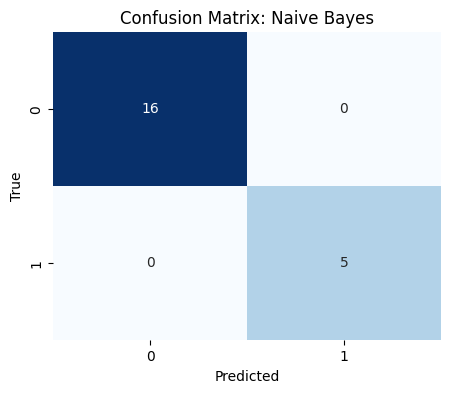


Training Gradient Boosting...
Accuracy: 0.9524
Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.94      0.97        16
         Yes       0.83      1.00      0.91         5

    accuracy                           0.95        21
   macro avg       0.92      0.97      0.94        21
weighted avg       0.96      0.95      0.95        21



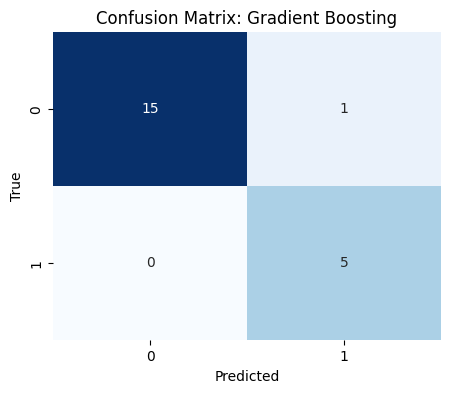


Training AdaBoost...
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        16
         Yes       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



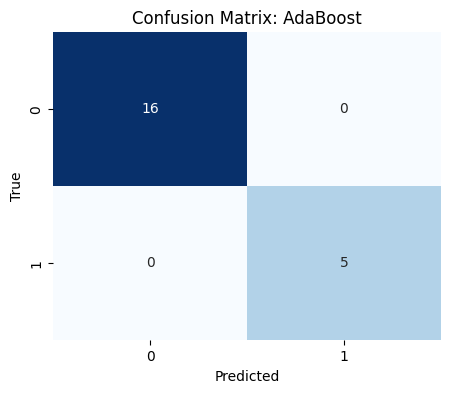

In [25]:
# 8. Train, Predict and Evaluate
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    
    results[name] = acc


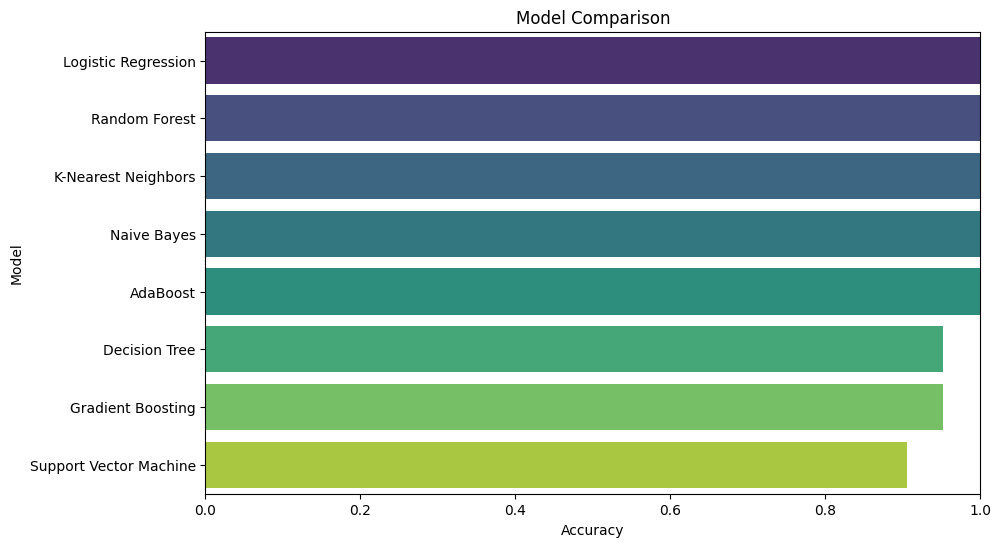


Best Model:
Model       Logistic Regression
Accuracy                    1.0
Name: 0, dtype: object


In [26]:
# 9. Compare all model accuracies
result_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=result_df, palette='viridis')
plt.title('Model Comparison')
plt.xlim(0, 1)
plt.show()

print("\nBest Model:")
print(result_df.iloc[0])

## THank you..pls upvote!!!